# Método de Jacobi.

**Objetivo.** 

Describir e implementar el algoritmo de Jacobi para la solución de sistemas de ecuaciones lineales.

**Trabajo realizado con el apoyo del Programa UNAM-DGAPA-PAPIME, proyectos PE101019, PE101922 y PE106025.**

[![License: CC BY-SA 4.0](https://img.shields.io/badge/License-CC_BY--SA_4.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)

<div class="alert alert-danger">

**Ojo**. Ejecuta la siguiente celda para que todo lo que sigue funcione correctamente.
</div>

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid") 
import dfsol

# Planteamiento.

Considera el siguiente sistema de ecuaciones lineales:

$$
\left(
\begin{array}{cc}
-2 & 1 \\
1 & -2
\end{array} \right)
\left(
\begin{array}{c}
x \\
y
\end{array} \right) =
-\left(
\begin{array}{c}
638.89 \\ 
238.89
\end{array} \right) \tag{1}
$$

Este sistema se puede escribir en términos de las siguientes dos ecuaciones de la recta:

$$
\begin{array}{ccc}
y & = &2x - 638.89 \\
y & = & \dfrac{x}{2} + 119.44 
\end{array}
$$

y de acuerdo con la ecuación general de la línea recta que es $y = mx + b$, tenemos que:
* Para la primera ecuación : $m_1 = 2$ y $b_1 = -638.89$.
* Para la segunda ecuación: $m_1 = \frac{1}{2}$ y $b_2 = 119.44$ .

Con estas definiciones de la recta se puede hacer una gráfica como sigue:

<div class="alert alert-info">

## Ejemplo 1.

En la siguiente celda definimos $m_1$, $b_1$, $m_2$, $b_2$, evaluamos las dos ecuaciones de la recta en el intervalo $x \in [100,800]$, y luego graficamos ambas rectas.

</div>

x = [100. 170. 240. 310. 380. 450. 520. 590. 660. 730. 800.]

m1 = 2
b1 = -638.89
y1 = [-438.89 -298.89 -158.89  -18.89  121.11  261.11  401.11  541.11  681.11
  821.11  961.11]

m2 = 0.5
b2 = 119.44
y2 = [169.44 204.44 239.44 274.44 309.44 344.44 379.44 414.44 449.44 484.44
 519.44]


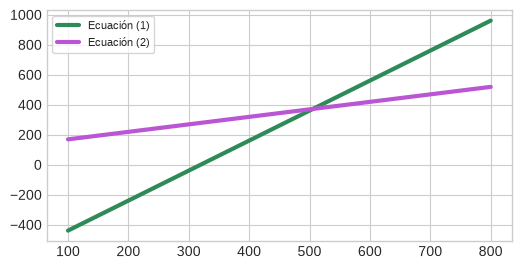

In [2]:
# Dominio
x = np.linspace(100,800,11)

# Línea recta 1
m1 = 2
b1 = -638.89
y1 = m1 * x + b1 # Evaluación

# Línea recta 2
m2 = 1/2.
b2 = 119.44
y2 = m2 * x + b2 # Evaluación

print(f"x = {x}\n")
print(f"m1 = {m1}")
print(f"b1 = {b1}")
print(f"y1 = {y1}\n")

print(f"m2 = {m2}")
print(f"b2 = {b2}")
print(f"y2 = {y2}")

# Graficamos las rectas
plt.figure(figsize=(6,3))
plt.plot(x, y1, lw = 3, c = "seagreen", label = "Ecuación (1)") # Línea recta 1
plt.plot(x, y2, lw = 3, c = "mediumorchid", label = "Ecuación (2)") # Línea recta 2
plt.legend(ncol = 1, frameon=True, loc="best", fontsize=8)
plt.grid(True)
plt.show()

<div class="alert alert-success">

**Pregunta**. ¿Qué representa el punto donde las rectas se cruzan?

</div>

<div class="alert alert-info">

## Ejemplo 2.

El sistema lineal $(1)$ definido en el planteamiento inicial de esta notebook, proviene de la aplicación del método de diferencias finitas a la ecuación de calor en una dimensión, en donde se usan los siguientes parámetros físicos: 

- $\kappa = 0.5$ [W /m $^o$C]
- $L = 0.02$ [m]
- $T_A = 100$ [$^o$C]
- $T_B = 200$ [$^o$C]
- $q = 5 \times 10^6$ [W/m$^3$]  (Flujo de calor)
- $N = 2$ (número de nodos)

La función `dfsol.sistema_lineal()`, definida en el archivo [`dfsol.py`](dfsol.py), crea la matriz del sistema y el RHS para este problema.

1. Utilizaremos esta función para almacenar la matriz en el arreglo `A` y el RHS en el arreglo `b` usando los datos antes descritos.

**Nota**. Observa que al principio de esta notebook se incluyeron las bibliotecas que se usarán en los ejemplos siguientes, particularmente: `import dfsol`.

</div>


In [3]:
# Definimos los parámetros físicos del problema
k = 1000
L = 0.5
TA = 500
TB = 100
q = 5e+6
N = 2

# Calculamos la matriz y el RHS del sistema
A, b = dfsol.sistema_lineal(TA, TB, q, L, k, N)

print(f"Matriz del sistema: \n{A}")
print(f"RHS: \n{b}")

Matriz del sistema: 
[[ 2. -1.]
 [-1.  2.]]
RHS: 
[638.88888889 238.88888889]


<div class="alert alert-info">

2. Resolvemos ahora el sistema con la función [`np.linalg.solve()`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html) y almacenamos la solución en el arreglo `sol`.

</div>

In [4]:
sol = np.linalg.solve(A,b) # Función del módulo linalg para resolver el sistema

print(f"Solución del sistema: \n{sol}")

Solución del sistema: 
[505.55555556 372.22222222]


<div class="alert alert-info">

3. Realizamos las gráficas de las líneas rectas y de la solución.
</div>


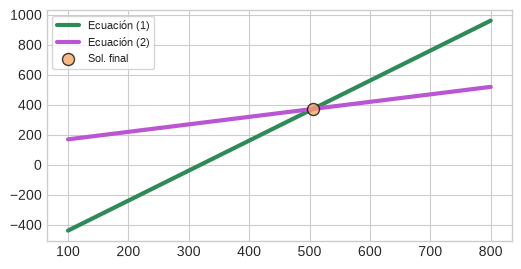

In [5]:
# Graficamos las rectas y la solución
plt.figure(figsize=(6,3))
plt.plot(x, y1, lw = 3, c = "seagreen", label = "Ecuación (1)") # Línea recta 1
plt.plot(x, y2, lw = 3, c = "mediumorchid", label = "Ecuación (2)") # Línea recta 2
plt.scatter(sol[0], sol[1], fc="sandybrown", ec="black", s = 75, alpha=0.75, zorder=5, label='Sol. final') # Solución
plt.legend(ncol = 1, frameon=True, loc="best", fontsize=8)
plt.grid(True)
plt.show()

<div class="alert alert-info">

**Nota**. Con esta gráfica ya sabes lo que representa el punto donde se cruzan las rectas.

</div>

# Descripición del método de Jacobi.

Tomando como base el sistema de ecuaciones lineales de $2 \times 2$ de los ejemplos anteriores, podemos escribirlo de la siguiente manera: 

$$
\begin{array}{ccccccc}
a_{11}u_1 & + & a_{12}u_2 & = & b_1 \\
a_{21}u_1 & + & a_{22}u_2 & = & b_2 \\
\end{array}
$$

donde $a_{ij}$ con $i,j = 1, 2$ son los coeficientes de la matriz del sistema, $(u_1, u_2)$ son las incógnitas y $(b_1, b_2)$ es el lado derecho (RHS) del sistema.

En el método de **Jacobi**, se despeja $u_1$ de la primera ecuación y $u_2$ de la segunda de tal manera que obtenemos:
$$
\begin{eqnarray*}
	u_1 & = & \dfrac{1}{a_{11}} \left( b_1 - (a_{12}u_2) \right) \\
	u_2 & = & \dfrac{1}{a_{22}} \left( b_2 - (a_{21}u_1) \right) \\
\end{eqnarray*}
$$

Suponemos ahora que tenemos una solución inicial aproximada $\mathbf{u}^0 = (u_1^0, u_2^0)$. Usando esta solución inicial, es posible hacer una nueva aproximación para obtener  $\mathbf{u}^1 = (u_1^1, u_2^1)$ como sigue:

$$
\begin{eqnarray*}
	u_1^1 & = & \dfrac{1}{a_{11}} \left( b_1 - (a_{12}u_2^0) \right) \\
	u_2^1 & = & \dfrac{1}{a_{22}} \left( b_2 - (a_{21}u_1^0) \right)  \\
\end{eqnarray*}
$$

Ahora tomando $(u_1^1, u_2^1)$ como una nueva aproximación a la solución, la usamos para calcular $(u_1^2, u_2^2)$:

$$
\begin{eqnarray*}
	u_1^2 & = & \dfrac{1}{a_{11}} \left( b_1 - (a_{12}u_2^1) \right) \\
	u_2^2 & = & \dfrac{1}{a_{22}} \left( b_2 - (a_{21}u_1^1) \right)  \\
\end{eqnarray*}
$$

Este proceso se puede repetir varias veces. Estas repeticiones se conocen como iteraciones y las etiquetamos con $k$. Entonces, para $k = 1, 2, \dots$ escribimos:

$$
\begin{eqnarray*}
	u_1^k & = & \dfrac{1}{a_{11}} \left( b_1 - (a_{12}u_2^{k-1}) \right) \\
	u_2^k & = & \dfrac{1}{a_{22}} \left( b_2 - (a_{21}u_1^{k-1}) \right)  \\
\end{eqnarray*}
$$

Para saber cuándo terminar con estas iteraciones, cálculamos el diferencia entre iteraciones, que se escribe como sigue:

$$
E^k = || (u_1, u_2)^k - (u_1, u_2)^{k-1}|| = || \mathbf{u}^k - \mathbf{u}^{k-1}|| \tag{3}
$$

El valor de $E^k$ debería disminuir en cada iteración, entonces podemos establecer una tolerancia, de tal manera que cuando $E^k$ sea menor a esa tolerancia entonces podemos terminar el proceso y quedarnos con $(u_1, u_2)^k$ cómo la última aproximación a la solución.

En general, para un sistema de ecuaciones lineales de $n \times n$, se puede escribir una ecuación general para este algoritmo como sigue:

$$
u_i^k = \frac{1}{a_{i,i}} \left(b_i -  \sum_{j \neq i} a_{i,j} u_j^{k-1} \right) \tag{4}
$$

que es válida para $i = 1, \dots, n$ y $k = 1, 2, \dots$.

## Algoritmo.
En general podemos definir el siguiente algoritmo para el método de Jacobi.
<center>
<img src="./algo_Jacobi.png"  width='500px'/>
</center>

**Observaciones.**

* En este algoritmo hay un ciclo `while` el cual termina cuando el error es menor o igual que una tolerancia (`tol`) o se ha alcanzado un número máximo de iteraciones (`kmax`).
* En la línea **11** se calcula la diferencia entre iteraciones consecutivas, que en términos matemáticos se define como $E = || \mathbf{u}^k - \mathbf{u}^{k-1}||$. A esta diferencia también se le conoce como error.

</div>

## Implementación.

En la siguiente celda se implementa el algoritmo de Jacobi. Revisa la implementación y comparala con el algoritmo. Ejecuta la celda para definir la función `jacobi()`.

In [6]:
def jacobi(A, b, tol, kmax, ui):
    N = len(b)
    unew = np.zeros(N)
    
    # Solución inicial
    uold = np.copy(ui)

    # Listas para los pasos intermedios y el error
    xs = [uold[0]]
    ys = [uold[1]]

    # Error  
    E = 10 # mayor que la tolerancia
    E_lista = [] # Lista para los errores
    
    print("{:^2} {:^10} {:^12} {:^12}".format(" i ", "Error", "u1", "u2"))
        
    k = 0
    while E > tol and k < kmax:
        for i in range(0,N): # se puede hacer en paralelo
            unew[i] = 0
            for j in range(0,i):
                unew[i] += A[i,j] * uold[j]
            for j in range(i+1,N):
                unew[i] += A[i,j] * uold[j]                
            unew[i] = (b[i] - unew[i]) / A[i,i]

        # Calculamos el error con respecto a la iter anterior
        E = np.linalg.norm(unew - uold)

        # Almacenamos los pasos y el error en las listas
        xs.append(unew[0])
        ys.append(unew[1])
        E_lista.append(E)
        
        # Incrementamos k y actualizamos xold
        k += 1
        uold = np.copy(unew)
        
        print("{:2d} {:10.9f} ({:10.9f}, {:10.9f})".format(k, E, unew[0], unew[1]))            
    return unew, xs, ys, E_lista, k

Observa que la función `jacobi()` regresa 5 valores: 

* `unew` la solución obtenida, 
* `xs` y `ys` componentes de las soluciones aproximadas en cada paso, 
* `E_lista` una lista con el error para cada iteración.
* `k` el número total de iteraciones realizadas.

<div class="alert alert-info">

## Ejemplo 3.

Haciendo uso de la función `jacobi` definida en la celda anterior, aproximaremos la solución del sistema de ecuaciones definido en el **Ejemplo 2**, utilizando los siguientes datos:

* Solución inicial `ui` = $(100, 100)$.
* Tolerancia `tol` = $1 \times 10^{-5}$.
* Número máximo de iteraciones `kmax` = $50$.

Posteriormente se realizan algunas gráficas.

</div>

 i    Error         u1           u2     
 1 278.249599292 (369.444444444, 169.444444444)
 2 139.124799646 (404.166666667, 304.166666667)
 3 69.562399823 (471.527777778, 321.527777778)
 4 34.781199912 (480.208333333, 355.208333333)
 5 17.390599956 (497.048611111, 359.548611111)
 6 8.695299978 (499.218750000, 367.968750000)
 7 4.347649989 (503.428819444, 369.053819444)
 8 2.173824994 (503.971354167, 371.158854167)
 9 1.086912497 (505.023871528, 371.430121528)
10 0.543456249 (505.159505208, 371.956380208)
11 0.271728124 (505.422634549, 372.024197049)
12 0.135864062 (505.456542969, 372.155761719)
13 0.067932031 (505.522325304, 372.172715929)
14 0.033966016 (505.530802409, 372.205607096)
15 0.016983008 (505.547247993, 372.209845649)
16 0.008491504 (505.549367269, 372.218068441)
17 0.004245752 (505.553478665, 372.219128079)
18 0.002122876 (505.554008484, 372.221183777)
19 0.001061438 (505.555036333, 372.221448686)
20 0.000530719 (505.555168788, 372.221962611)
21 0.000265359 (505.555425750, 3

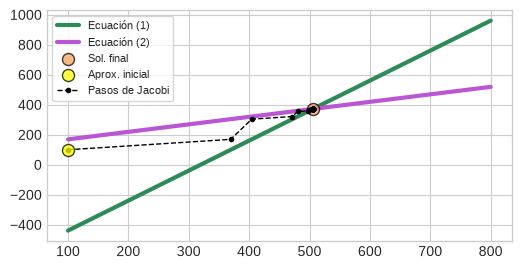

In [7]:
ui = np.array([100, 100])
tol = 1e-5
kmax = 50

# Ejecución del método de Jacobi
solJ, xs, ys, error, it = jacobi(A, b, tol, kmax, ui)

# Graficamos las rectas, la solución y los pasos.
plt.figure(figsize=(6,3))
plt.plot(x, y1, lw = 3, c = "seagreen", label = "Ecuación (1)") # Línea recta 1
plt.plot(x, y2, lw = 3, c = "mediumorchid", label = "Ecuación (2)") # Línea recta 2
plt.scatter(sol[0], sol[1], fc="sandybrown", ec="black", s = 75, alpha=0.75, 
            zorder=5, label='Sol. final') # Solución

# Graficamos los pasos
plt.scatter(xs[0], ys[0], fc="yellow", ec="black", s = 75, alpha=0.75, 
            zorder=8, label="Aprox. inicial")
plt.plot(xs, ys, c="black", marker = ".", ls = "--", lw=1.0, 
         zorder=7, label="Pasos de Jacobi")

plt.legend(ncol = 1, frameon=True, loc="best", fontsize=8)
plt.grid(True)
plt.show()

<div class="alert alert-success">

**Pregunta**.
¿Qué crees que pasará si cambiamos la solución inicial (punto amarillo)?

</div>

<div class="alert alert-info">

Graficamos el error que se va obteniendo en cada paso del algoritmo.
</div>

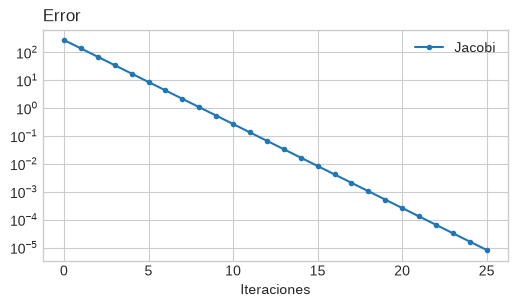

In [8]:
# Gráfica del error
plt.figure(figsize=(6,3))
plt.title("Error", loc="left")
plt.plot(list(range(0,it)), error, marker=".", label="Jacobi")
plt.xlabel("Iteraciones")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert alert-info">

**Nota**. Observa que efectivamente el error va disminuyendo conforme avanzamos en las iteraciones hasta alcanzar la tolerancia impuesta.

</div>

<div class="alert alert-success">

**Pregunta**.
¿Que crees que pasará si cambiamos el valor de la tolerancia (`tol`)?

</div>

Almacenamos el error en el archivo `zd_errorJacobi.npy` y los pasos en el archivo `zd_pasosJacobi.npy`.

In [9]:
dir_data = Path("datos")
dir_data.mkdir(parents=True, exist_ok=True)

np.save("./datos/zd_errorJacobi.npy", error)
np.save("./datos/zd_pasosJacobi.npy", np.array([xs,ys]))

Checamos que se pueden leer los archivos con la función `np.load()`:

In [10]:
print("Error Jacobi = \n{}\n".format(np.load("./datos/zd_errorJacobi.npy")))
print("(xs, ys) = \n{}\n".format(np.load("./datos/zd_pasosJacobi.npy")))

Error Jacobi = 
[2.78249599e+02 1.39124800e+02 6.95623998e+01 3.47811999e+01
 1.73906000e+01 8.69529998e+00 4.34764999e+00 2.17382499e+00
 1.08691250e+00 5.43456249e-01 2.71728124e-01 1.35864062e-01
 6.79320311e-02 3.39660155e-02 1.69830078e-02 8.49150388e-03
 4.24575194e-03 2.12287597e-03 1.06143799e-03 5.30718993e-04
 2.65359496e-04 1.32679748e-04 6.63398741e-05 3.31699370e-05
 1.65849685e-05 8.29248427e-06]

(xs, ys) = 
[[100.         369.44444444 404.16666667 471.52777778 480.20833333
  497.04861111 499.21875    503.42881944 503.97135417 505.02387153
  505.15950521 505.42263455 505.45654297 505.5223253  505.53080241
  505.54724799 505.54936727 505.55347866 505.55400848 505.55503633
  505.55516879 505.55542575 505.55545886 505.5555231  505.55553138
  505.55554744 505.55554951]
 [100.         169.44444444 304.16666667 321.52777778 355.20833333
  359.54861111 367.96875    369.05381944 371.15885417 371.43012153
  371.95638021 372.02419705 372.15576172 372.17271593 372.2056071
  372.209